# Activity 2: Analyzing Different Scenarios and Generating the Appropriate Visualization

We'll be working with the 120 years of Olympic History dataset acquired by Randi Griffin from https://www.sports-reference.com/ and made available on the GitHub repository of this book. Your assignment is to identify the top five sports based on the largest number of medals awarded in the year 2016, and then perform the following analysis:

1.  Generate a plot indicating the number of medals awarded in each of the top five sports in 2016.
2.  Plot a graph depicting the distribution of the age of medal winners in the top five sports in 2016.
3.  Find out which national teams won the largest number of medals in the top five sports in 2016.
4.  Observe the trend in the average weight of male and female athletes winning in the top five sports in 2016.

## High-Level Steps

1.  Download the dataset and format it as a pandas DataFrame.
2.  Filter the DataFrame to only include the rows corresponding to medal winners from 2016.
3.  Find out the medals awarded in 2016 for each sport.
4.  List the top five sports based on the largest number of medals awarded. Filter the DataFrame one more time to only include the records for the top five sports in 2016.
5.  Generate a bar plot of record counts corresponding to each of the top five sports.
6.  Generate a histogram for the Age feature of all medal winners in the top five sports (2016).
7.  Generate a bar plot indicating how many medals were won by each country's team in the top five sports in 2016.
8.  Generate a bar plot indicating the average weight of players, categorized based on gender, winning in the top five sports in 2016.

Top 5 Sports in 2016 by Medals Awarded:
['Athletics', 'Swimming', 'Rowing', 'Football', 'Hockey']


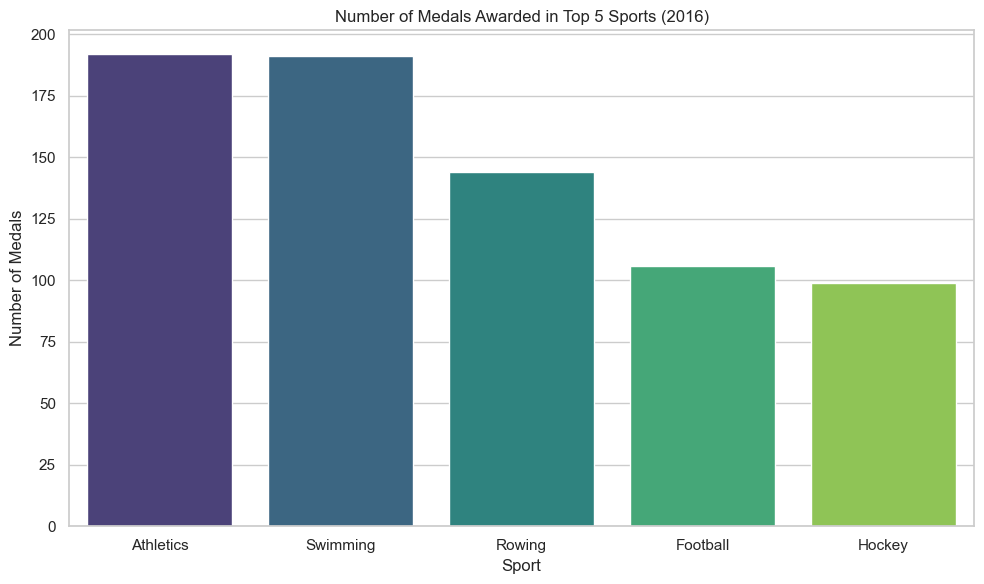

c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


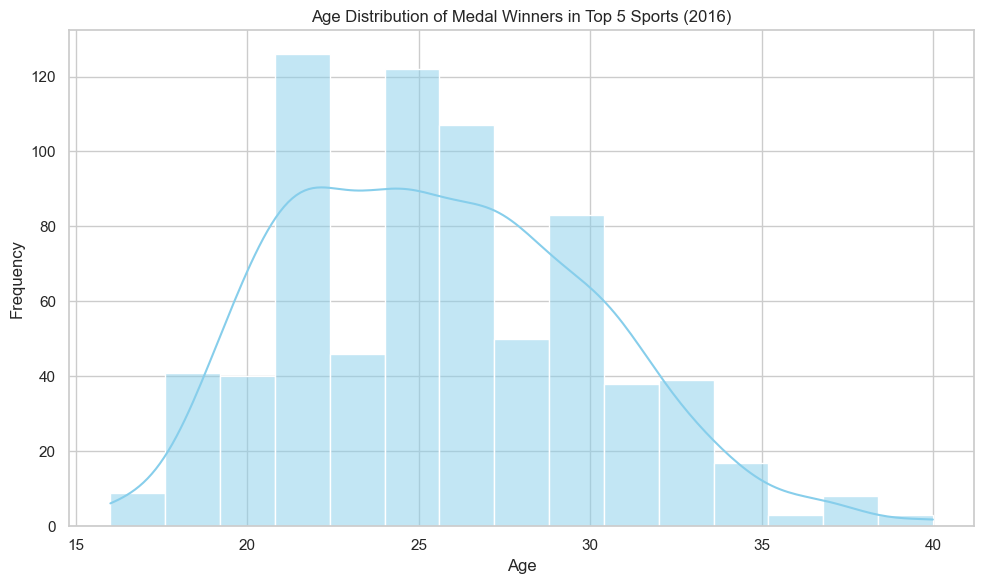

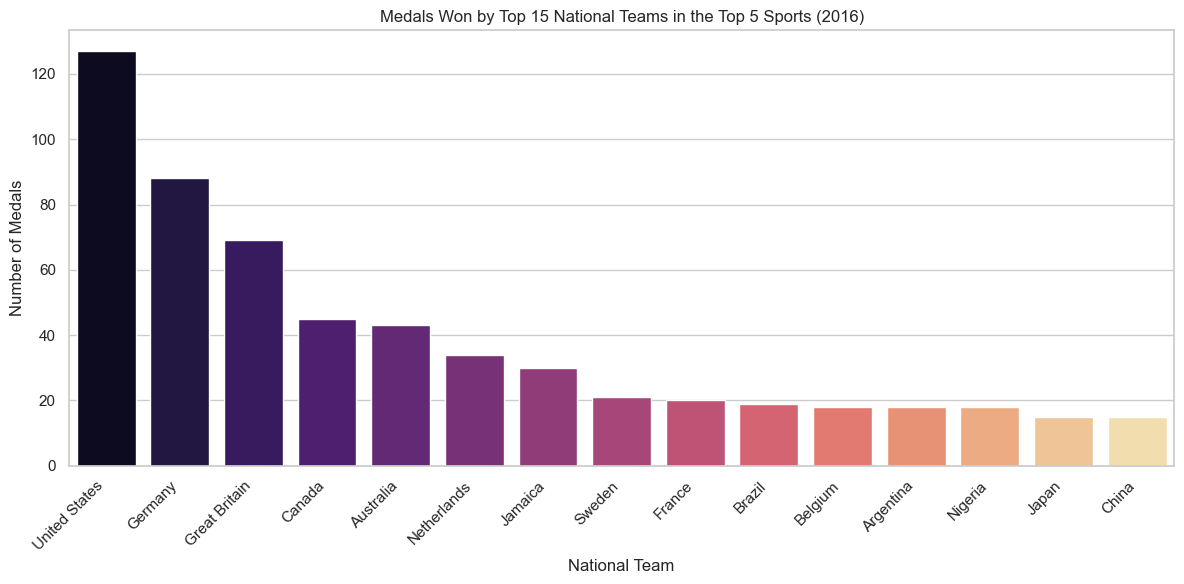

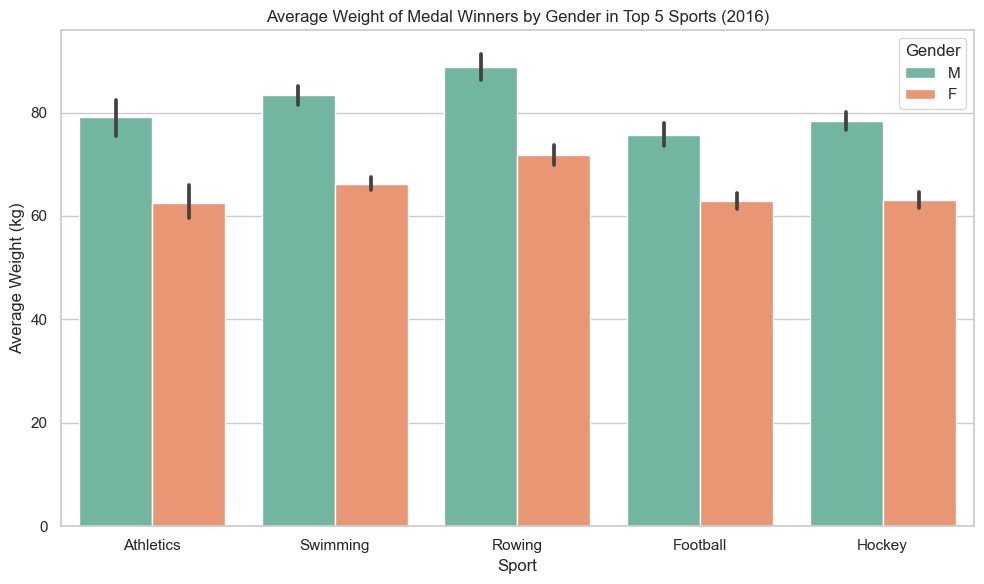

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for the plots
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------------------------------
# 1. Download the dataset and format it as a pandas DataFrame
# ---------------------------------------------------------------------------------
# Note: Replace the URL/Path with the exact link to your book's GitHub repository 
# or local path if you have downloaded it.
url = "https://raw.githubusercontent.com/rgriff23/Olympic_history/master/data/athlete_events.csv"
df = pd.read_csv(url)

# ---------------------------------------------------------------------------------
# 2. Filter the DataFrame to only include medal winners from 2016
# ---------------------------------------------------------------------------------
# We filter by Year == 2016 and drop rows where the 'Medal' column is NaN
df_2016_medals = df[(df['Year'] == 2016) & (df['Medal'].notna())]

# ---------------------------------------------------------------------------------
# 3. Find out the medals awarded in 2016 for each sport
# ---------------------------------------------------------------------------------
medals_per_sport = df_2016_medals.groupby('Sport')['Medal'].count().reset_index()
medals_per_sport.rename(columns={'Medal': 'Medal_Count'}, inplace=True)

# ---------------------------------------------------------------------------------
# 4. List the top five sports based on the largest number of medals awarded.
#    Filter the DataFrame to only include the records for the top five sports.
# ---------------------------------------------------------------------------------
top_5_sports_df = medals_per_sport.sort_values(by='Medal_Count', ascending=False).head(5)
top_5_sports_list = top_5_sports_df['Sport'].tolist()

print("Top 5 Sports in 2016 by Medals Awarded:")
print(top_5_sports_list)

# Filter the 2016 dataset to only include these top 5 sports
df_top5 = df_2016_medals[df_2016_medals['Sport'].isin(top_5_sports_list)]

# ---------------------------------------------------------------------------------
# 5. Generate a bar plot of record counts corresponding to each of the top five sports
# ---------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.countplot(data=df_top5, x='Sport', order=top_5_sports_list, palette='viridis')
plt.title('Number of Medals Awarded in Top 5 Sports (2016)')
plt.xlabel('Sport')
plt.ylabel('Number of Medals')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------
# 6. Generate a histogram for the Age feature of all medal winners in the top five sports
# ---------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.histplot(df_top5['Age'].dropna(), bins=15, kde=True, color='skyblue')
plt.title('Age Distribution of Medal Winners in Top 5 Sports (2016)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------
# 7. Generate a bar plot indicating how many medals were won by each country's 
#    team in the top five sports in 2016
# ---------------------------------------------------------------------------------
# We'll calculate the total medals per team in these top 5 sports. 
# (Showing the top 15 teams to ensure the chart is readable).
team_medals = df_top5.groupby('Team')['Medal'].count().reset_index()
team_medals = team_medals.sort_values(by='Medal', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=team_medals, x='Team', y='Medal', palette='magma')
plt.title('Medals Won by Top 15 National Teams in the Top 5 Sports (2016)')
plt.xlabel('National Team')
plt.ylabel('Number of Medals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------
# 8. Generate a bar plot indicating the average weight of players, categorized 
#    based on gender, winning in the top five sports in 2016.
# ---------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
# By default, seaborn's barplot calculates the mean (average) of the y variable
sns.barplot(data=df_top5, x='Sport', y='Weight', hue='Sex', palette='Set2', order=top_5_sports_list)
plt.title('Average Weight of Medal Winners by Gender in Top 5 Sports (2016)')
plt.xlabel('Sport')
plt.ylabel('Average Weight (kg)')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()